# Starlink Flyovers over London:

In [ ]:
# Imports:
from datetime import datetime
from skyfield.api import load
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Time Array:
ts = load.timescale()
length = 3600*1.5 # in seconds
orbit_duration = np.arange(0, length + 1, 1)
epochs_of_orbit = ts.utc(2025, 6, 15, 12, 25, 8 + orbit_duration)
ref_locations = [["London",51.5,0.128], ["REACH",-30.7,-21.5]]

In [ ]:
from astrotrack.preprocess import load_satellite_data

data = load_satellite_data(
    tle_file="../../data/TLE-catalogues/TLEs.txt",
    target_date=datetime(2025, 6, 15, 12, 25, 8),
    obs_len=length,
    traj_res=10,
    obs_lat=-30.71131,
    obs_lon=21.4476236,
    R=1500,
    horizon_data="../../data/horizon-profiles/REACH-Horizon.csv",
    satcon="starlink"
)

Processing satellites:   0%|          | 0/107 [00:00<?, ?satellite/s]

Processing satellites: 100%|██████████| 107/107 [00:11<00:00,  8.97satellite/s]


In [ ]:
n_flyovers = len(data)
norads = []
for flyover in data:
    tle_2 = flyover['TLE'][1].split(" ")  # get NORAD from TLE line 2
    norads.append(tle_2[1])  # append NORADs

print(f"Number of Starlink Flyovers over London: {len(data)}")

C:\Users\lette\OneDrive\Desktop\Publications\RASTI AstroTrack Paper\astrotrack\astrotrack\satcon_properties.py:302: UserWarning: no explicit representation of timezones available for np.datetime64
  epochs_np = np.array([np.datetime64(e) for e in epochs])


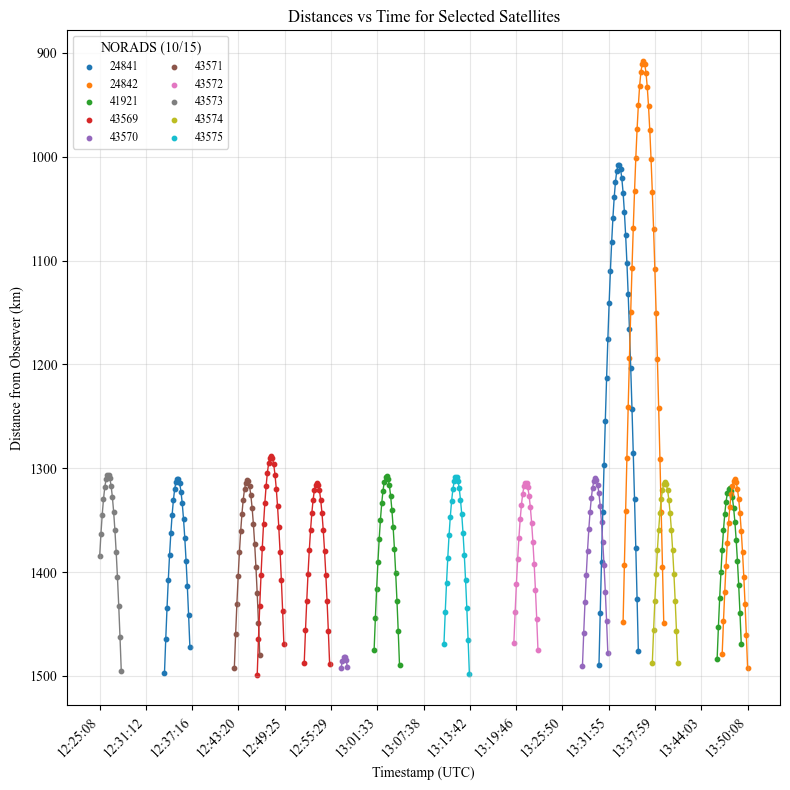

In [ ]:
from astrotrack.satcon_properties import plot_max_elevation_histogram

plot_max_elevation_histogram(
    data,
    font_family="Times New Roman",
    figsize=(8, 8),
    color="lightpink",
    edgecolor="deeppink"
)